In [1]:
import pandas as pd
import numpy as np

In [ ]:
# df = pd.read_csv('/Users/jeffwinchell/Documents/cmu/coursework/spring_2026/funbio/cell-cycle-ti/data/GSE142277/GSE142277_RAW/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt',sep='\t')
# df = pd.read_csv('../data/toy_datasets/swiss_0.5noise.csv')

In [ ]:
# drop zero-expressed genes
# df[df.values[:,1:].astype(int).sum(axis=1)>0].reset_index(drop=True).shape

#### more sample datasets

In [263]:
def generate_toroidal_helix(major_r=100, minor_r=10, turns=20, num_points=1000):
    """Generates a 3D toroidal helix dataset."""
    t = np.linspace(0, 2 * np.pi, num_points)
    
    # Parametric equations for a Toroidal Helix
    x = (major_r + minor_r * np.cos(turns * t)) * np.cos(t)
    y = (major_r + minor_r * np.cos(turns * t)) * np.sin(t)
    z = minor_r * np.sin(turns * t)
    
    return pd.DataFrame({'x': x,'y': y, 'z': z})

def make_tree(n=3000, split_ts=(0.35, 0.65), branch_probs=(0.6, 0.3, 0.1),
              noise=0.03, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.random(n)
    b = np.zeros(n, dtype=int)  # 0 trunk, 1/2/3 branches

    split1, split2 = split_ts

    after1 = t >= split1
    b[after1] = rng.choice([1,2,3], size=after1.sum(), p=branch_probs)

    X = np.zeros((n, 2))
    for i in range(n):
        if t[i] < split1:
            s = t[i]/split1
            X[i] = [s, 0.0]
        else:
            s = (t[i]-split1)/(1-split1)
            base = np.array([1.0, 0.0])
            if b[i] == 1:      # up branch
                X[i] = base + [0.9*s, 0.8*s]
            elif b[i] == 2:    # down branch
                X[i] = base + [0.9*s, -0.8*s]
            else:              # “late” branch that peels off later
                if t[i] < split2:
                    u = (t[i]-split1)/(split2-split1)
                    X[i] = base + [0.9*u, 0.15*np.sin(2*np.pi*u)]
                else:
                    u = (t[i]-split2)/(1-split2)
                    mid = base + [0.9, 0.0]
                    X[i] = mid + [0.4*u, 0.9*u]

    X += rng.normal(scale=noise, size=X.shape)
    return X, t, b

X,_,_ = make_tree(seed=None)

In [267]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.stats import zscore

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

def revelio_like_preprocess(
    counts_df,
    marker_dict,
    min_cells_per_gene=5,
    min_genes_per_cell=1200,
    max_umi_per_cell=10**7,
    min_phase_top_z=1.0,
    min_phase_margin=0,
    min_mean=0.2,
    max_mean=4,
    min_disp=0.5,
    n_pcs=50,
):
    """
    counts_df: genes x cells raw UMI counts (DataFrame)
    marker_dict: ordered dict-like mapping phase -> list of marker genes
    """

    # ----------------------------
    # 1) Create AnnData
    # ----------------------------
    adata = ad.AnnData(X=counts_df.T.values.astype(float))
    adata.obs_names = counts_df.columns.astype(str)
    adata.var_names = counts_df.index.astype(str)

    # ----------------------------
    # 2) QC filtering
    # ----------------------------
    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

    adata.obs["nUMI"] = np.asarray(adata.X.sum(axis=1)).ravel()
    adata.obs["nGene"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

    keep = (adata.obs["nGene"] > min_genes_per_cell) & (adata.obs["nUMI"] < max_umi_per_cell)
    adata = adata[keep].copy()

    # ----------------------------
    # 3) Normalize to median UMI, then log1p
    # ----------------------------
    target_sum = float(np.median(np.asarray(adata.X.sum(axis=1)).ravel()))
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)

    # Keep a copy of normalized/log data
    adata.layers["log_of_fractions"] = adata.X.copy()

    # ----------------------------
    # 4) Phase scoring
    # ----------------------------
    phase_names = list(marker_dict.keys())

    marker_dict_present = {
        ph: [g for g in genes if g in adata.var_names]
        for ph, genes in marker_dict.items()
    }

    # optional sanity check
    for ph, genes in marker_dict_present.items():
        print(ph, len(genes), genes[:10])

    score_mat = np.zeros((adata.n_obs, len(phase_names)), dtype=float)

    for j, ph in enumerate(phase_names):
        genes = marker_dict_present[ph]
        if len(genes) == 0:
            continue
        idx = adata.var_names.get_indexer(genes)
        score_mat[:, j] = np.asarray(adata[:, idx].X.mean(axis=1)).ravel()

    phase_scores = pd.DataFrame(score_mat, index=adata.obs_names, columns=phase_names)

    # column-wise z-score, then row-wise z-score
    arr = phase_scores.values
    arr = (arr - arr.mean(axis=0)) / arr.std(axis=0, ddof=0)
    arr = (arr - arr.mean(axis=1, keepdims=True)) / arr.std(axis=1, keepdims=True, ddof=0)
    arr = np.nan_to_num(arr)

    phase_scores_z = pd.DataFrame(arr, index=phase_scores.index, columns=phase_scores.columns)

    # ----------------------------
    # 5) Extract best phase / confidence
    # ----------------------------
    best_idx = arr.argmax(axis=1)
    best_val = arr[np.arange(arr.shape[0]), best_idx]

    arr2 = arr.copy()
    arr2[np.arange(arr.shape[0]), best_idx] = -np.inf
    second_idx = arr2.argmax(axis=1)
    second_val = arr2[np.arange(arr2.shape[0]), second_idx]

    phase_margin = best_val - second_val

    adata.obs["cc_phase"] = pd.Categorical(
        [phase_names[i] for i in best_idx],
        categories=phase_names,
        ordered=True
    )
    adata.obs["best_val"] = best_val
    adata.obs["second_val"] = second_val
    adata.obs["phase_margin"] = phase_margin

    adata.obsm["phase_scores"] = phase_scores.values
    adata.obsm["phase_scores_z"] = phase_scores_z.values

    # ----------------------------
    # 6) Filter to confident cycling cells
    # ----------------------------
    keep = (adata.obs["best_val"] > min_phase_top_z) & (adata.obs["phase_margin"] > min_phase_margin)
    adata = adata[keep].copy()

    # ----------------------------
    # 7) HVG selection
    # ----------------------------
    sc.pp.highly_variable_genes(
        adata,
        min_mean=min_mean,
        max_mean=max_mean,
        min_disp=min_disp
    )
    adata = adata[:, adata.var["highly_variable"]].copy()

    # ----------------------------
    # 8) Scale genes, then PCA
    # ----------------------------
    sc.pp.scale(adata)
    sc.tl.pca(adata, n_comps=n_pcs)

    return adata

In [268]:
gene_set_df = pd.read_excel('../data/GSE142277/gene_sets_GSE142277.xlsx',sheet_name="Gene Sets Used in Analysis")
marker_dict = {}
for cc in gene_set_df.columns:
    marker_dict[cc] = list(gene_set_df[cc].dropna().apply(lambda x: x.strip()).values)

print(marker_dict)
# marker_dict = {
#     "G1.S": ["MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2"],
#     "S":    ["RAD51", "RPA2", "NASP", "CDC45", "ASF1B", "EXO1", "DSCC1", "BLM"],
#     "G2":   ["CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "TOP2A", "CENPF"],
#     "G2.M": ["HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "AURKB"],
#     "M.G1": ["CDC20", "PTTG1", "CDC25C", "ANLN", "ESPL1", "KIF20B", "PLK1"],
# }

{'G1/S': ['ACD', 'ACYP1', 'ADAMTS1', 'ANKRD10', 'APEX2', 'ARGLU1', 'ATAD2', 'BARD1', 'BRD7', 'C1orf63', 'C7orf41', 'C14orf142', 'CAPN7', 'CASP2', 'CASP8AP2', 'CCNE1', 'CCNE2', 'CDC6', 'CDC25A', 'CDCA7', 'CDCA7L', 'CEP57', 'CHAF1A', 'CHAF1B', 'CLSPN', 'CREBZF', 'CTSD', 'DIS3', 'DNAJC3', 'DONSON', 'DSCC1', 'DTL', 'E2F1', 'EIF2A', 'ESD', 'FAM105B', 'FAM122A', 'FLAD1', 'GINS2', 'GINS3', 'GMNN', 'HELLS', 'HOXB4', 'HRAS', 'HSF2', 'INSR', 'INTS8', 'IVNS1ABP', 'KIAA1147', 'KIAA1586', 'LNPEP', 'LUC7L3', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MDM1', 'MED31', 'MRI1', 'MSH2', 'NASP', 'NEAT1', 'NKTR', 'NPAT', 'NUP43', 'ORC1', 'OSBPL6', 'PANK2', 'PCDH7', 'PCNA', 'PLCXD1', 'PMS1', 'PNN', 'POLD3', 'RAB23', 'RECQL4', 'RMI2', 'RNF113A', 'RNPC3', 'SEC62', 'SKP2', 'SLBP', 'SLC25A36', 'SNHG10', 'SRSF7', 'SSR3', 'TAF15', 'TIPIN', 'TOPBP1', 'TRA2A', 'TTC14', 'UBR7', 'UHRF1', 'UNG', 'USP53', 'VPS72', 'WDR76', 'ZMYND19', 'ZNF367', 'ZRANB2'], 'S': ['ABCC5', 'ABHD10', 'ANKRD18A', 'ASF1B', 'ATAD2', 'BBS2', 'BIVM', 'BLM

/opt/anaconda3/envs/pfs/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [272]:
adata.obs['cc_phase'].value_counts()

cc_phase
G1/S    242
S       137
M/G1    129
M        88
G2/M     81
Name: count, dtype: int64

In [273]:
import anndata as ad
import scanpy as sc
import pandas as pd
# Load raw data
wt_data = pd.read_csv(
    '/Users/jeffwinchell/Documents/cmu/coursework/spring_2026/funbio/cell-cycle-ti/data/GSE142277/GSE142277_RAW/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt',
    sep='\t',
    index_col=0
)
adata = revelio_like_preprocess(wt_data,marker_dict)

# # genes × cells → transpose to cells × genes for AnnData
# adata = ad.AnnData(X=wt_data.T.astype(float))
# print(adata.shape)
# # # library size normalization
# # sc.pp.normalize_total(adata, target_sum=1e4)



# # filtering (matches paper)
# sc.pp.filter_genes(adata, min_cells=5)
# sc.pp.filter_cells(adata, min_genes=500)


# # log1p
# sc.pp.log1p(adata)

# # Highly variable genes
# # sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# # adata = adata[:, adata.var.highly_variable].copy()


# # # optional: scale before PCA
# # sc.pp.scale(adata, max_value=10)

# # PCA 
# sc.tl.pca(adata, n_comps=50)

# import numpy as np
# import scanpy as sc
# import anndata as ad

# adata = ad.AnnData(X=wt_data.T.astype(float))



# # normalization (match κ = median UMI)
# target = np.median(np.array(adata.X.sum(axis=1)).ravel())
# sc.pp.normalize_total(adata, target_sum=target)

# # log transform
# sc.pp.log1p(adata)

# # variable genes (match thresholds)
# sc.pp.highly_variable_genes(
#     adata,
#     min_mean=0.2,
#     max_mean=4,
#     min_disp=0.5
# )
# adata = adata[:, adata.var.highly_variable].copy()

# # z-score (CRITICAL)
# sc.pp.scale(adata)

# # PCA
# sc.tl.pca(adata, n_comps=50)
# print(adata)
# print("PCA shape:", adata.obsm['X_pca'].shape)

G1/S 96 ['ACD', 'ACYP1', 'ADAMTS1', 'ANKRD10', 'APEX2', 'ARGLU1', 'ATAD2', 'BARD1', 'BRD7', 'C14orf142']
S 110 ['ABCC5', 'ABHD10', 'ANKRD18A', 'ASF1B', 'ATAD2', 'BBS2', 'BIVM', 'BLM', 'BMI1', 'BRCA1']
G2/M 132 ['ANLN', 'AP3D1', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB', 'BCLAF1', 'BORA']
M 150 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARL6IP1', 'ASXL1', 'ATF7IP']
M/G1 105 ['AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'CBX3', 'CDC42']


#### KNN graph

In [251]:
from sklearn.neighbors import NearestNeighbors

# we can do this from scratch
X = adata.obsm['X_pca']
k = 30
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

## Diffusion Maps

In [252]:
import numpy as np
N = X.shape[0]
K = np.zeros((N,N)) # will update this to be a CSR

#
alpha = 0.5
for i in range(len(indices)):
    for j in range(k):
        K[i,indices[i,j]] = np.exp(-distances[i,j]**2 /(distances[i,k-1]*distances[indices[i,j],k-1])) # adaptive kernel

K = (K+K.T)/2 # symmetrize

# density normalization
K_tilde = K.copy()
q = np.sum(K_tilde,axis=1)
scale = q ** (-alpha)
K_tilde = (scale[:, None] * K) * scale[None, :] 


# # row normalize
# row_sums = np.array(K_tilde.sum(axis=1)).flatten()
# P = K_tilde*(1/row_sums[:,None]) # MARKOV MATRIX

# D = K_tilde.sum(axis=1).ravel() # diagonal matrix of row sums (as vector)

# D_inv_sqrt = 1/np.sqrt(D)
# D_sqrt = np.sqrt(D)

# S = (D_sqrt[:, None] * P) * D_inv_sqrt[None, :] # symmetric matrix (D^0.5 @ P @ D^(-0.5))

# print(np.max(np.abs(S-S.T))) # should be very small

In [253]:
from scipy.sparse.csgraph import connected_components

connected_components(K_tilde)[0]

1

#### QC

In [254]:
# # 1) row sums ~ 1
# rs = np.asarray(P.sum(axis=1)).ravel()
# print(rs.min(), rs.max())

# # 2) nonnegativity
# print(P.min())

# # 3) sparsity
# print(np.nonzero(P)[0].shape[0], "nonzeros out of", P.shape[0]**2)

In [255]:
from scipy.sparse.linalg import eigs
from scipy.sparse import diags
import numpy as np
from scipy.sparse.linalg import eigsh  # for symmetric conjugate matrix S
def diffusion_map_from_Ktilde(K_tilde, n_components=30, t=1, eps=1e-12):
    """
    K_tilde: symmetric sparse matrix after density normalization, before row-normalization
    Returns:
        emb:    (N, n_components) diffusion embedding
        lambdas:(n_components,) nontrivial eigenvalues
        psis:   (N, n_components) right eigenvectors of P
    """
    d = np.asarray(K_tilde.sum(axis=1)).ravel()
    d = np.maximum(d, eps)

    # symmetric conjugate S = D^{-1/2} K_tilde D^{-1/2}
    inv_sqrt_d = 1.0 / np.sqrt(d)
    D_inv_sqrt = diags(inv_sqrt_d)
    S = D_inv_sqrt @ K_tilde @ D_inv_sqrt

    # top eigenpairs
    vals, vecs = eigsh(S, k=n_components + 1, which="LA")
    order = np.argsort(-vals)
    vals = vals[order]
    vecs = vecs[:, order]

    # drop trivial first eigenpair
    lambdas = vals[1:n_components + 1]
    u = vecs[:, 1:n_components + 1]

    # right eigenvectors of P
    psis = u * inv_sqrt_d[:, None]

    # diffusion coordinates at time t
    emb = psis * (lambdas ** t)

    return emb, lambdas, psis

emb, lambdas, psis = diffusion_map_from_Ktilde(K_tilde,) # diffusion components, eigenvals, eigenvectors



def diffusion_pseudotime(psis, lambdas, root=0, eps=1e-12):
    """
    psis:    (N, n_components)
    lambdas: (n_components,)
    root:    root cell index

    Returns:
        dpt: (N,) pseudotime/diffusion distance from root
    """
    denom = np.maximum(1.0 - lambdas, eps)  # avoid division by zero
    diff = psis - psis[root, :]             # subtract root from every cell
    dpt_sq = np.sum((diff ** 2) / denom[None, :], axis=1)
    dpt = np.sqrt(dpt_sq)
    return dpt

dpt = diffusion_pseudotime(psis,lambdas)

In [256]:
adata.obs['dpt'] = dpt
from scipy.stats import rankdata
dpt_rank = (rankdata(dpt) - 1) / (len(dpt) - 1)
adata.obs['dpt_rank'] = dpt_rank

<Axes: xlabel='dpt_rank', ylabel='cc_phase'>

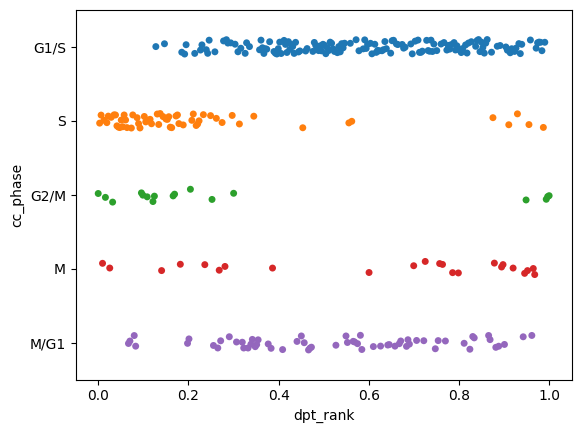

In [257]:
import seaborn as sns

sns.stripplot(data=adata.obs,x='dpt_rank',y='cc_phase',hue='cc_phase')

In [258]:
for ph, genes in marker_dict.items():
    present = [g for g in genes if g in adata.var_names]
    print(ph, len(present), present[:10])

G1/S 31 ['ATAD2', 'BARD1', 'CASP8AP2', 'CCNE2', 'CDC6', 'CDCA7', 'CHAF1A', 'CHAF1B', 'CLSPN', 'CREBZF']
S 38 ['ATAD2', 'BIVM', 'BRCA1', 'BRIP1', 'C5orf42', 'CALM2', 'CDKN2AIP', 'CENPM', 'CHML', 'COQ9']
G2/M 45 ['ANLN', 'AP3D1', 'AURKB', 'BRD8', 'CCDC107', 'CCNA2', 'CCNF', 'CDCA2', 'CDCA3', 'CDCA8']
M 61 ['ANLN', 'ANP32E', 'ARL6IP1', 'AURKA', 'BIRC2', 'BIRC5', 'BUB1', 'CCDC88A', 'CCNA2', 'CCNB2']
M/G1 31 ['AKAP13', 'ANP32E', 'ANTXR1', 'CDK7', 'CDKN3', 'DSP', 'DYNLL1', 'FAM60A', 'HIF1A', 'HMG20B']


In [259]:
arr = lambdas.copy()
# 1. Sort the array
sorted_arr = np.sort(arr)
# 2. Find differences between adjacent elements
diffs = np.diff(sorted_arr)
# 3. Find index of the smallest difference
min_idx = np.argmin(diffs)
# 4. The closest pair is:
closest_pair = (sorted_arr[min_idx], sorted_arr[min_idx + 1])
print(f"Closest pair: {closest_pair}") # Output: (2, 5)

Closest pair: (np.float64(0.8753866677124502), np.float64(0.8774152046415228))


IndexError: index 500 is out of bounds for axis 0 with size 314

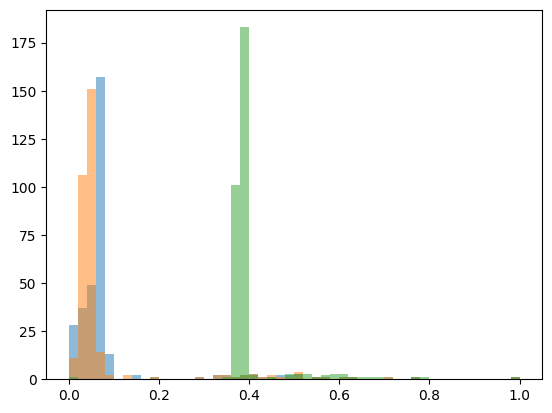

In [260]:
for root in [0, 100, 300, 500]:
    dpt = diffusion_pseudotime(psis, lambdas, root=root)
    dpt = (dpt - dpt.min()) / (dpt.max() - dpt.min())
    plt.hist(dpt, bins=50, alpha=0.5, label=f"root={root}")
plt.legend()
plt.show()

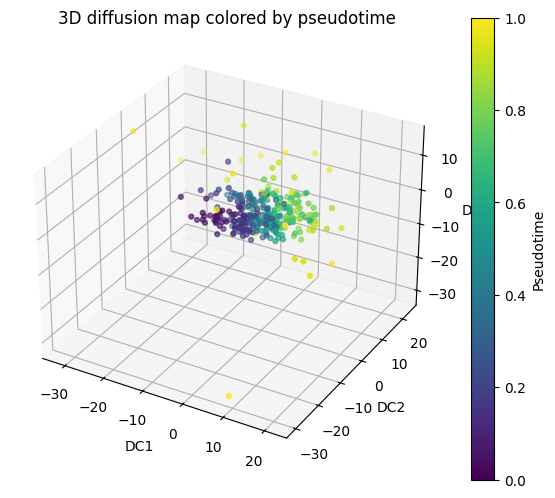

In [261]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=dpt_rank,
    s=12
)

ax.set_xlabel("DC1")
ax.set_ylabel("DC2")
ax.set_zlabel("DC3")
ax.set_title("3D diffusion map colored by pseudotime")
fig.colorbar(sc, ax=ax, label="Pseudotime")

plt.show()
# # 3D Plot
# import seaborn as sns
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# df[['diff_1','diff_2']] = emb[:,[0,1]]
# fig = plt.figure(figsize=(6,6),dpi=150)
# ax = Axes3D(fig, auto_add_to_figure=False)
# fig.add_axes(ax)

# sc = ax.scatter(df['x'],df['y'],df['z'],c=df['diff_1'])
# ax.set_title("First Diffusion Component on Swiss Roll")
# fig.tight_layout()

# 2D plot
# import seaborn as sns
# import matplotlib.pyplot as plt

# fig, ax= plt.subplots(figsize=(6,6),dpi=150)
# # ax = Axes3D(fig, auto_add_to_figure=False)
# # fig.add_axes(ax)

# sc = ax.scatter(df['x'],df['y'],c=df['diff_1'])
# ax.set_title("First Diffusion Component on Branch")
# fig.tight_layout()


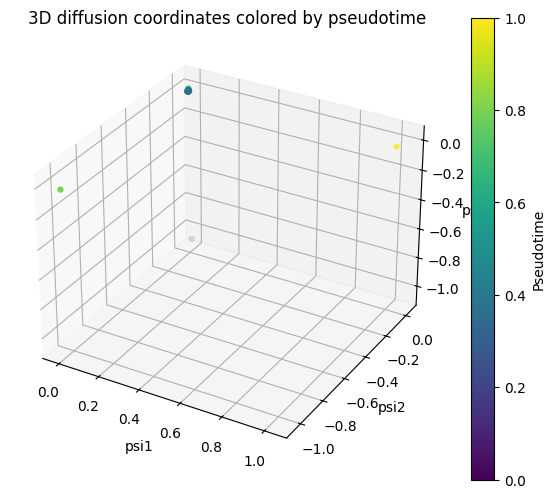

In [262]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    psis[:, 0], psis[:, 1], psis[:, 2],
    c=dpt,
    s=12
)

ax.set_xlabel("psi1")
ax.set_ylabel("psi2")
ax.set_zlabel("psi3")
ax.set_title("3D diffusion coordinates colored by pseudotime")
fig.colorbar(sc, ax=ax, label="Pseudotime")

plt.show()